# BC_Gaussian Oracle Success Rates

**Date:** 2026-03-17
**Purpose:** Train the same 6 BC_Gaussian policies from v0.2.5.9, save them to disk, and collect 50 oracle rollouts each to get ground-truth success rates.

v0.2.5.9 used NLL as a proxy for policy quality (Spearman rho=0.21, fail). This notebook gets the real oracle SR so we can re-evaluate whether guidance ranking works with proper ground truth.

In [1]:
import sys, os, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
from pathlib import Path
from copy import deepcopy

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
CKPT_RUN_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/lift_diffusion_100demos/20260311135551"
SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "bc_gaussians"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

OBS_KEYS = sorted(["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"])
STATE_DIM = 19
ACTION_DIM = 7
HORIZON = 60
NUM_ROLLOUTS = 50

# BC_Gaussian training config (same as v0.2.5.9)
BC_HIDDEN_DIMS = [256, 256]
BC_LR = 1e-4
BC_BATCH_SIZE = 256

TARGETS = [
    {"name": "bc_10demos_e50",   "filter_key": "10_demos",  "epochs": 50},
    {"name": "bc_10demos_e200",  "filter_key": "10_demos",  "epochs": 200},
    {"name": "bc_25demos_e100",  "filter_key": "25_demos",  "epochs": 100},
    {"name": "bc_50demos_e100",  "filter_key": "50_demos",  "epochs": 100},
    {"name": "bc_100demos_e100", "filter_key": "100_demos", "epochs": 100},
    {"name": "bc_200demos_e100", "filter_key": None,         "epochs": 100},
]

print(f"Save dir: {SAVE_DIR}")
print(f"Rollouts per policy: {NUM_ROLLOUTS}")
print(f"Horizon: {HORIZON}")

Device: cuda
Save dir: /home1/reishuen/latent_sope/diffusion_ckpts/bc_gaussians
Rollouts per policy: 50
Horizon: 60


In [2]:
# ── GaussianPolicy definition (identical to v0.2.5.9) ──

class GaussianPolicy(nn.Module):
    """Simple Gaussian policy: MLP -> (mean, std) per action dimension."""
    
    def __init__(self, obs_dim, action_dim, hidden_dims=[256, 256],
                 init_std=0.3, min_std=0.01, max_std=7.5):
        super().__init__()
        self.action_dim = action_dim
        self.min_std = min_std
        self.max_std = max_std
        
        layers = []
        in_dim = obs_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(in_dim, action_dim)
        self.log_std_head = nn.Linear(in_dim, action_dim)
        
        init_bias = np.log(np.exp(init_std) - 1.0)
        nn.init.constant_(self.log_std_head.bias, init_bias)
        nn.init.zeros_(self.log_std_head.weight)
    
    def forward(self, obs):
        h = self.backbone(obs)
        mean = self.mean_head(h)
        raw_std = self.log_std_head(h)
        std = torch.clamp(F.softplus(raw_std), min=self.min_std, max=self.max_std)
        return mean, std
    
    def log_prob(self, obs, action):
        mean, std = self.forward(obs)
        dist = torch.distributions.Normal(mean, std)
        return dist.log_prob(action).sum(-1)
    
    def sample_action(self, obs_tensor):
        """Sample a single action for rollout (no grad)."""
        with torch.no_grad():
            mean, std = self.forward(obs_tensor)
            dist = torch.distributions.Normal(mean, std)
            return dist.sample()
    
    def train_on_data(self, obs, actions, n_epochs, batch_size=256, lr=1e-4):
        opt = torch.optim.Adam(self.parameters(), lr=lr)
        dev = next(self.parameters()).device
        obs_t = torch.tensor(obs, dtype=torch.float32, device=dev)
        act_t = torch.tensor(actions, dtype=torch.float32, device=dev)
        N = len(obs_t)
        steps_per_epoch = max(1, N // batch_size)
        
        self.train()
        losses = []
        for epoch in range(n_epochs):
            epoch_loss = 0.0
            perm = torch.randperm(N, device=dev)
            for step in range(steps_per_epoch):
                idx = perm[step * batch_size:(step + 1) * batch_size]
                if len(idx) == 0:
                    continue
                nll = -self.log_prob(obs_t[idx], act_t[idx]).mean()
                opt.zero_grad()
                nll.backward()
                opt.step()
                epoch_loss += nll.item()
            losses.append(epoch_loss / max(1, steps_per_epoch))
        
        self.eval()
        return losses

print(f"GaussianPolicy defined. Params: {sum(p.numel() for p in GaussianPolicy(STATE_DIM, ACTION_DIM).parameters()):,}")

GaussianPolicy defined. Params: 74,510


In [3]:
# ── Load demo data and train policies (same as v0.2.5.9) ──

def load_demos(hdf5_path, filter_key=None, obs_keys=None):
    all_obs, all_acts = [], []
    with h5py.File(hdf5_path, "r") as f:
        if filter_key is not None:
            demo_keys = [k.decode() if isinstance(k, bytes) else k 
                         for k in f[f"mask/{filter_key}"][:]]
        else:
            demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
        for dk in demo_keys:
            demo = f[f"data/{dk}"]
            obs = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in obs_keys], axis=-1)
            acts = demo["actions"][:].astype(np.float32)
            all_obs.append(obs)
            all_acts.append(acts)
    return np.concatenate(all_obs, axis=0), np.concatenate(all_acts, axis=0)

print("Training BC_Gaussian policies...\n")
bc_policies = {}
t0_all = time.time()

for tgt in TARGETS:
    name = tgt["name"]
    obs, acts = load_demos(DEMO_HDF5, tgt["filter_key"], OBS_KEYS)
    print(f"  {name:<22} {len(obs):>6} transitions, {tgt['epochs']} epochs", end=" ", flush=True)
    t0 = time.time()
    
    # Set seed for reproducibility (same as v0.2.5.9)
    torch.manual_seed(42)
    np.random.seed(42)
    
    policy = GaussianPolicy(STATE_DIM, ACTION_DIM, hidden_dims=BC_HIDDEN_DIMS).to(device)
    losses = policy.train_on_data(obs, acts, n_epochs=tgt["epochs"], batch_size=BC_BATCH_SIZE, lr=BC_LR)
    bc_policies[name] = policy
    
    # Save to disk
    save_path = SAVE_DIR / f"{name}.pt"
    torch.save({
        "model_state_dict": policy.state_dict(),
        "obs_dim": STATE_DIM,
        "action_dim": ACTION_DIM,
        "hidden_dims": BC_HIDDEN_DIMS,
        "final_loss": losses[-1],
        "n_epochs": tgt["epochs"],
        "filter_key": tgt["filter_key"],
        "n_transitions": len(obs),
    }, save_path)
    
    print(f"-> loss={losses[-1]:.4f}, saved to {save_path.name}, {time.time()-t0:.0f}s")

print(f"\nTotal training: {time.time()-t0_all:.0f}s")
print(f"Saved {len(bc_policies)} policies to {SAVE_DIR}")

Training BC_Gaussian policies...

  bc_10demos_e50            511 transitions, 50 epochs 

-> loss=3.1764, saved to bc_10demos_e50.pt, 3s
  bc_10demos_e200           511 transitions, 200 epochs 

-> loss=-4.5415, saved to bc_10demos_e200.pt, 0s
  bc_25demos_e100          1218 transitions, 100 epochs 

-> loss=-4.3260, saved to bc_25demos_e100.pt, 1s
  bc_50demos_e100          2447 transitions, 100 epochs 

-> loss=-4.7493, saved to bc_50demos_e100.pt, 2s
  bc_100demos_e100         4898 transitions, 100 epochs 

-> loss=-5.8237, saved to bc_100demos_e100.pt, 4s


  bc_200demos_e100         9666 transitions, 100 epochs 

-> loss=-7.5813, saved to bc_200demos_e100.pt, 7s

Total training: 18s
Saved 6 policies to /home1/reishuen/latent_sope/diffusion_ckpts/bc_gaussians


In [4]:
# ── Create Lift environment from existing robomimic checkpoint ──
from src.latent_sope.robomimic_interface.checkpoints import load_checkpoint, build_env_from_checkpoint

ckpt = load_checkpoint(CKPT_RUN_DIR)
env = build_env_from_checkpoint(ckpt, render=False, render_offscreen=False, verbose=False)
print(f"Env created: {type(env)}")

# Quick sanity check: reset and inspect obs keys
test_obs = env.reset()
print(f"Obs keys: {sorted(test_obs.keys())}")
for k in OBS_KEYS:
    print(f"  {k}: shape={test_obs[k].shape}")

# Verify obs concatenation matches STATE_DIM
concat_dim = sum(test_obs[k].shape[-1] for k in OBS_KEYS)
assert concat_dim == STATE_DIM, f"Expected {STATE_DIM}, got {concat_dim}"
print(f"\nConcatenated obs dim: {concat_dim} (matches STATE_DIM={STATE_DIM})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[robosuite WARNING] No private macro file found! (macros.py:57)


...

[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


Created environment with name Lift
Action size is 7
ROBOMIMIC WARNING(
    Dataset and installed environment version mismatch!
    Dataset environment version: 1.5.1
    Installed environment version: 1.5.2
)


[18:01:11] INFO     build_env_from_checkpoint took 18.46 seconds to execute                           ]8;id=716448;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=977893;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

Env created: <class 'robomimic.envs.wrappers.FrameStackWrapper'>


Obs keys: ['actions', 'lang_emb', 'object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_acc', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'timesteps']
  object: shape=(2, 10)
  robot0_eef_pos: shape=(2, 3)
  robot0_eef_quat: shape=(2, 4)
  robot0_gripper_qpos: shape=(2, 2)

Concatenated obs dim: 19 (matches STATE_DIM=19)


In [5]:
# ── Oracle rollouts for each BC_Gaussian policy ──

def obs_dict_to_tensor(obs_dict, obs_keys, dev):
    """Concatenate obs dict into a (1, STATE_DIM) tensor for the policy.
    Handles frame-stacked obs by taking the last frame."""
    parts = []
    for k in obs_keys:
        v = np.asarray(obs_dict[k], dtype=np.float32)
        if v.ndim > 1:
            v = v[-1]  # take last frame if frame-stacked
        parts.append(v.flatten())
    vec = np.concatenate(parts)
    return torch.tensor(vec, dtype=torch.float32, device=dev).unsqueeze(0)

def obs_dict_to_latent(obs_dict, obs_keys):
    """Concatenate obs dict into a (STATE_DIM,) numpy array.
    Handles frame-stacked obs by taking the last frame."""
    parts = []
    for k in obs_keys:
        v = np.asarray(obs_dict[k], dtype=np.float32)
        if v.ndim > 1:
            v = v[-1]  # take last frame if frame-stacked
        parts.append(v.flatten())
    return np.concatenate(parts)

def rollout_bc_gaussian(policy, env, horizon, obs_keys, dev):
    """Run one rollout with a GaussianPolicy in the Lift env. Records full trajectory."""
    obs = env.reset()
    state_dict = env.get_state()
    obs = env.reset_to(state_dict)
    
    total_reward = 0.0
    success = False
    latents_list = []
    actions_list = []
    rewards_list = []
    dones_list = []
    
    for step_i in range(horizon):
        latents_list.append(obs_dict_to_latent(obs, obs_keys))
        obs_t = obs_dict_to_tensor(obs, obs_keys, dev)
        action = policy.sample_action(obs_t).squeeze(0).cpu().numpy()
        actions_list.append(action)
        
        next_obs, reward, done, info = env.step(action)
        total_reward += reward
        rewards_list.append(reward)
        success = env.is_success()["task"]
        dones_list.append(done or success)
        
        if done or success:
            # Record terminal obs so success state is captured
            latents_list.append(obs_dict_to_latent(next_obs, obs_keys))
            break
        obs = deepcopy(next_obs)
    
    return {
        "total_reward": total_reward,
        "success": success,
        "steps": step_i + 1,
        "latents": np.array(latents_list, dtype=np.float32),
        "actions": np.array(actions_list, dtype=np.float32),
        "rewards": np.array(rewards_list, dtype=np.float32),
        "dones": np.array(dones_list, dtype=np.bool_),
    }

# Run oracle rollouts
print(f"Running {NUM_ROLLOUTS} oracle rollouts per policy (horizon={HORIZON})...")
print(f"Estimated time: ~{NUM_ROLLOUTS * len(TARGETS) * 15 / 60:.0f} min\n")

oracle_results = {}
all_trajectories = {}  # name -> list of rollout dicts
t0_all = time.time()

for tgt in TARGETS:
    name = tgt["name"]
    policy = bc_policies[name]
    policy.eval()
    
    print(f"  {name:<22}", end=" ", flush=True)
    t0 = time.time()
    
    successes = []
    rewards = []
    trajectories = []
    for i in range(NUM_ROLLOUTS):
        result = rollout_bc_gaussian(policy, env, HORIZON, OBS_KEYS, device)
        successes.append(result["success"])
        rewards.append(result["total_reward"])
        trajectories.append(result)
        if (i + 1) % 10 == 0:
            print(f"[{i+1}]", end="", flush=True)
    
    sr = np.mean(successes)
    mean_reward = np.mean(rewards)
    oracle_results[name] = {
        "success_rate": sr,
        "mean_reward": mean_reward,
        "std_reward": np.std(rewards),
        "successes": successes,
        "rewards": rewards,
    }
    all_trajectories[name] = trajectories
    elapsed = time.time() - t0
    print(f" SR={sr*100:.0f}%, reward={mean_reward:.1f}, {elapsed:.0f}s")

total_time = time.time() - t0_all
print(f"\nTotal rollout time: {total_time:.0f}s ({total_time/60:.1f} min)")

Running 50 oracle rollouts per policy (horizon=60)...
Estimated time: ~75 min

  bc_10demos_e50         

[10]

[20]

[30]

[40]

...

[20]

[30]

[40]

[50]

 SR=16%, reward=0.2, 90s

Total rollout time: 540s (9.0 min)


In [6]:
# ── Save rollout trajectories as .h5 files ──
# One directory per policy under rollouts/bc_gaussians/<policy_name>/

ROLLOUT_BASE = PROJECT_ROOT / "rollouts" / "bc_gaussians"

for tgt in TARGETS:
    name = tgt["name"]
    trajs = all_trajectories[name]
    rollout_dir = ROLLOUT_BASE / name
    rollout_dir.mkdir(parents=True, exist_ok=True)
    
    for j, traj in enumerate(trajs):
        path = rollout_dir / f"rollout_{j:04d}.h5"
        with h5py.File(path, "w") as f:
            f.create_dataset("latents", data=traj["latents"], compression="gzip")
            f.create_dataset("actions", data=traj["actions"], compression="gzip")
            f.create_dataset("rewards", data=traj["rewards"], compression="gzip")
            f.create_dataset("dones", data=traj["dones"], compression="gzip")
            f.create_dataset("t", data=np.arange(len(traj["actions"]), dtype=np.int64))
            f.attrs["success"] = int(traj["success"])
            f.attrs["total_reward"] = float(traj["total_reward"])
            f.attrs["horizon"] = int(traj["steps"])
            f.attrs["frame_stack"] = 1  # no frame stacking for BC_Gaussian
    
    n_success = sum(t["success"] for t in trajs)
    print(f"  {name:<22} {len(trajs)} rollouts saved ({n_success} successes) -> {rollout_dir}")

print(f"\nAll rollouts saved under {ROLLOUT_BASE}")

  bc_10demos_e50         50 rollouts saved (0 successes) -> /home1/reishuen/latent_sope/rollouts/bc_gaussians/bc_10demos_e50


  bc_10demos_e200        50 rollouts saved (0 successes) -> /home1/reishuen/latent_sope/rollouts/bc_gaussians/bc_10demos_e200


  bc_25demos_e100        50 rollouts saved (0 successes) -> /home1/reishuen/latent_sope/rollouts/bc_gaussians/bc_25demos_e100


  bc_50demos_e100        50 rollouts saved (0 successes) -> /home1/reishuen/latent_sope/rollouts/bc_gaussians/bc_50demos_e100


  bc_100demos_e100       50 rollouts saved (0 successes) -> /home1/reishuen/latent_sope/rollouts/bc_gaussians/bc_100demos_e100


  bc_200demos_e100       50 rollouts saved (8 successes) -> /home1/reishuen/latent_sope/rollouts/bc_gaussians/bc_200demos_e100

All rollouts saved under /home1/reishuen/latent_sope/rollouts/bc_gaussians


In [7]:
# ── Save oracle results as JSON ──
import matplotlib.pyplot as plt

oracle_save_dir = PROJECT_ROOT / "diffusion_ckpts" / "bc_gaussians" / "oracle_results"
oracle_save_dir.mkdir(parents=True, exist_ok=True)

for tgt in TARGETS:
    name = tgt["name"]
    r = oracle_results[name]
    save_path = oracle_save_dir / f"{name}_oracle.json"
    data = {
        "policy_name": name,
        "success_rate": r["success_rate"],
        "mean_reward": r["mean_reward"],
        "std_reward": r["std_reward"],
        "num_rollouts": NUM_ROLLOUTS,
        "horizon": HORIZON,
        "returns": r["rewards"],
        "filter_key": next(t["filter_key"] for t in TARGETS if t["name"] == name),
        "epochs": next(t["epochs"] for t in TARGETS if t["name"] == name),
    }
    with open(save_path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"Saved: {save_path.name}")

print(f"\nOracle results saved to {oracle_save_dir}")

Saved: bc_10demos_e50_oracle.json
Saved: bc_10demos_e200_oracle.json
Saved: bc_25demos_e100_oracle.json
Saved: bc_50demos_e100_oracle.json
Saved: bc_100demos_e100_oracle.json
Saved: bc_200demos_e100_oracle.json

Oracle results saved to /home1/reishuen/latent_sope/diffusion_ckpts/bc_gaussians/oracle_results


In [8]:
# ── Summary table and visualization ──

print("=" * 75)
print("BC_GAUSSIAN ORACLE SUCCESS RATES (50 rollouts each, horizon=60)")
print("=" * 75)

# Get NLL from saved checkpoints for comparison with v0.2.5.9
print(f"\n{'Policy':<22} {'Filter':>10} {'Epochs':>7} {'Oracle SR':>10} {'Mean Rew':>10} {'Std Rew':>9}")
print("-" * 72)

names = [t["name"] for t in TARGETS]
srs = []
for tgt in TARGETS:
    name = tgt["name"]
    r = oracle_results[name]
    fk = tgt["filter_key"] or "all (200)"
    srs.append(r["success_rate"])
    print(f"{name:<22} {fk:>10} {tgt['epochs']:>6} {r['success_rate']*100:>9.0f}% "
          f"{r['mean_reward']:>10.2f} {r['std_reward']:>9.2f}")

print(f"\nSR range: [{min(srs)*100:.0f}%, {max(srs)*100:.0f}%]")
print(f"SR spread: {(max(srs) - min(srs))*100:.0f}%")

# Check if policies are monotonically ordered by demo count
# (expect more demos -> higher SR)
print(f"\nMonotonicity check (more demos -> higher SR?):")
for i in range(len(TARGETS) - 1):
    n1, n2 = TARGETS[i]["name"], TARGETS[i+1]["name"]
    s1, s2 = oracle_results[n1]["success_rate"], oracle_results[n2]["success_rate"]
    arrow = "+" if s2 >= s1 else "X"
    print(f"  {arrow} {n1} ({s1*100:.0f}%) -> {n2} ({s2*100:.0f}%)")

# v0.2.5.9 guided SR comparison
v259_guided = {
    "bc_10demos_e50": 0.52, "bc_10demos_e200": 0.60,
    "bc_25demos_e100": 0.58, "bc_50demos_e100": 0.76,
    "bc_100demos_e100": 0.52, "bc_200demos_e100": 0.52,
}

print(f"\n{'Policy':<22} {'Oracle SR':>10} {'v0.2.5.9 Guided':>16}")
print("-" * 52)
guided_srs = []
oracle_srs = []
for tgt in TARGETS:
    name = tgt["name"]
    osr = oracle_results[name]["success_rate"]
    gsr = v259_guided[name]
    oracle_srs.append(osr)
    guided_srs.append(gsr)
    print(f"{name:<22} {osr*100:>9.0f}% {gsr*100:>15.0f}%")

from scipy import stats
rho, p = stats.spearmanr(oracle_srs, guided_srs)
print(f"\nSpearman rho (Oracle SR vs v0.2.5.9 Guided SR): {rho:+.4f} (p={p:.4f})")

BC_GAUSSIAN ORACLE SUCCESS RATES (50 rollouts each, horizon=60)

Policy                     Filter  Epochs  Oracle SR   Mean Rew   Std Rew
------------------------------------------------------------------------
bc_10demos_e50           10_demos     50         0%       0.00      0.00
bc_10demos_e200          10_demos    200         0%       0.00      0.00
bc_25demos_e100          25_demos    100         0%       0.00      0.00
bc_50demos_e100          50_demos    100         0%       0.00      0.00
bc_100demos_e100        100_demos    100         0%       0.00      0.00
bc_200demos_e100        all (200)    100        16%       0.16      0.37

SR range: [0%, 16%]
SR spread: 16%

Monotonicity check (more demos -> higher SR?):
  + bc_10demos_e50 (0%) -> bc_10demos_e200 (0%)
  + bc_10demos_e200 (0%) -> bc_25demos_e100 (0%)
  + bc_25demos_e100 (0%) -> bc_50demos_e100 (0%)
  + bc_50demos_e100 (0%) -> bc_100demos_e100 (0%)
  + bc_100demos_e100 (0%) -> bc_200demos_e100 (16%)

Policy           

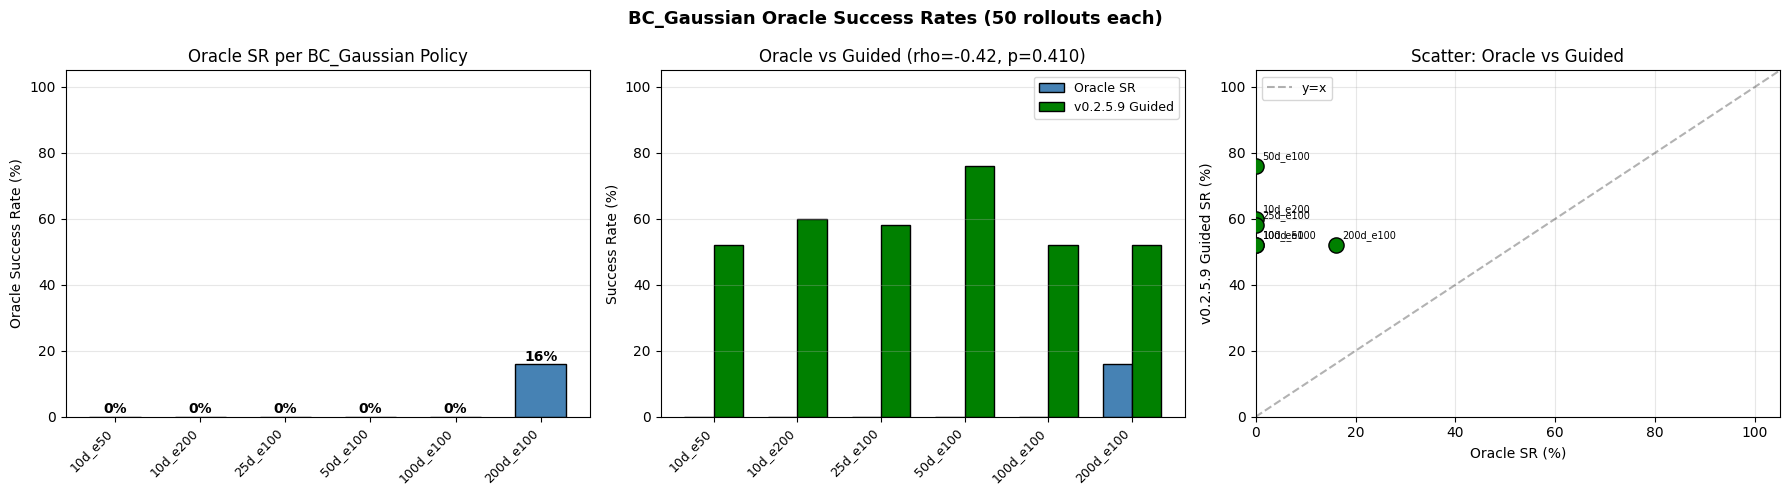


Done!


In [9]:
# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

short_names = [t["name"].replace("bc_", "").replace("demos_", "d_") for t in TARGETS]

# Panel 1: Oracle SR bar chart
ax = axes[0]
x = np.arange(len(TARGETS))
ax.bar(x, np.array(srs) * 100, color="steelblue", edgecolor="black", width=0.6)
for i, sr in enumerate(srs):
    ax.text(i, sr * 100 + 1, f"{sr*100:.0f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Oracle Success Rate (%)")
ax.set_title("Oracle SR per BC_Gaussian Policy")
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis="y")

# Panel 2: Oracle SR vs v0.2.5.9 Guided SR
ax = axes[1]
w = 0.35
ax.bar(x - w/2, np.array(oracle_srs) * 100, w, color="steelblue", edgecolor="black", label="Oracle SR")
ax.bar(x + w/2, np.array(guided_srs) * 100, w, color="green", edgecolor="black", label="v0.2.5.9 Guided")
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Success Rate (%)")
ax.set_title(f"Oracle vs Guided (rho={rho:+.2f}, p={p:.3f})")
ax.legend(fontsize=9)
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis="y")

# Panel 3: Oracle SR vs Guided SR scatter
ax = axes[2]
ax.scatter(np.array(oracle_srs) * 100, np.array(guided_srs) * 100,
           s=120, c="green", edgecolor="black", zorder=5)
for i, name in enumerate(short_names):
    ax.annotate(name, (oracle_srs[i]*100, guided_srs[i]*100),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
# Perfect correlation line
lims = [0, 105]
ax.plot(lims, lims, "k--", alpha=0.3, label="y=x")
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("v0.2.5.9 Guided SR (%)")
ax.set_title(f"Scatter: Oracle vs Guided")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("BC_Gaussian Oracle Success Rates (50 rollouts each)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nDone!")